# Time-series Dense Encoder Model (TiDE)

Por favor, leed primero el notebook del tft antes que este, se hará refrencias al mismo.

Este notebook es dependiente a pytorch y librerias similares. Se recomienda correr el notebook en un docker apropieado externo, o en su defecto, en un servicio web.

### Librerias necesarias

In [1]:
# Descargamos todo lo necesario para el TiDe
import lightning.pytorch as pl_train
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint
from pytorch_forecasting.models import TiDEModel
from pytorch_forecasting.data import TimeSeriesDataSet
from pytorch_forecasting.data.encoders import MultiNormalizer, GroupNormalizer
from pytorch_forecasting.metrics import SMAPE, MultiLoss

# Descargamos polars para el manejo de datos
import polars as pl

# Descargamos torch para el manejo de tensores
import torch

# Descargamos numpy para el manejo de arrays
import numpy as np

# Descargamos matplotlib para la visualización de datos
import matplotlib.pyplot as plt

# para medir el tiempo de entrenamiento
from time import time

## Paradigma general

Pese a que TFT (Temporal Fusion Transformer) es un modelo muy potente y con una capacidad de predicción admirable, en un proyecto de tan bajos recursos computacionales tratar solo un mes a 3 épocas nos costaría horas.

Google sacó en 2023 un modelo basado en el perceptrón multicapa, el TiDE. Este modelo se creó para solventar la lentitud de entreno de un multi-head-attention y los embeddings, permitiendo así un entrenamiento más eficaz a cambio de una ligera pérdida de rendimiento.

En este notebook desarrollaremos en todo detalle toda la teoría detras del modelo además de aplicarlo a nuestro problema con los datos de enero de 2025, los cuales adaptaremos al esquema de este modelo.

## Fundamentos teóricos

### Ideas principales:

Para entender cómo funciona este modelo, hay que entender cómo funciona un autoencoder, ya que su estructura de encoder-decoder es lo que permite que este modelo funcione.

### Encoder, un pasado codificado:

El encoder es el encargado de representar los invariantes temporales y todos los datos del pasado y transformarlo en un vector.
Este paso tiene dos funciones clave:
- __Feature projection__:  Básicamente se encarga de reducir la dimensión de las entradas dinámicas.
- __Dense encoder__: Una capa densa que genera un embedding.

### Decoder, el futuro a predecir:

La entrada del decoder, como ocure en un autoencoder, es el embedding generado por el dense encoder, este embedding pasa por 2 fases:

- __Dense decoder__: Funcionando como el proceso inverso al encoder, transforma el embdedding a un vector por cada paso temporal.
- __Temporal Decoder__: Junta las variables futuras conocidas con el vector anteriior para crear las predicciones.

### Esquema gráfico:
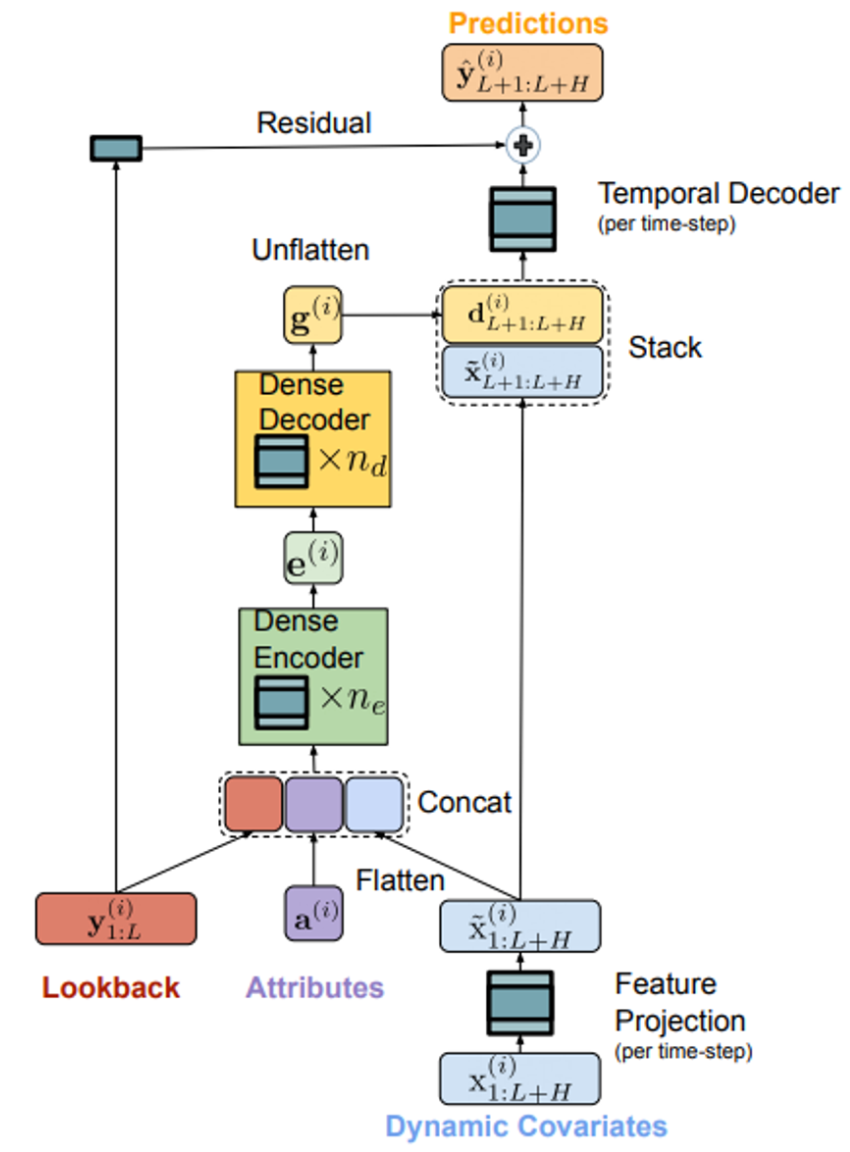

## Implementación del modelo:

Hay muchas implementaciones disponibles, más aún se podría programar a bajo nivel con keras y tensorflow o pytorch. Viendo que pytorch lo tiene en su repertorio de modelos y tiene un dtataset especial para series temporales, optaremos por usar este para esta presentación. Los datos que usaremos puede que no esten en el repositorio, pero descargandolos con la API del mismo funcionaría el código.

### Descarga y procesamiento de los datos

In [ ]:
import sys
from pathlib import Path

root = Path.cwd().parent / "minio_utils"
sys.path.append(str(root))

from minio_script import MinioPD2

path = Path.cwd()
if not Path(path, "data").exists():
    path = path.parent
path_data = path / "data" / "january.parquet"
minio = MinioPD2()
minio.download_file(path / "data", file_name=path_data.name)

In [ ]:
lz = pl.scan_parquet(path_data)

In [3]:
def prepare_tft_dataset(lf: pl.LazyFrame):
    # 1. Truncar a 30 minutos y Agrupar
    final_df = (
        lf.with_columns(
            [pl.col("pickup_datetime").dt.truncate("30m").alias("pickup_interval")]
        )
        .group_by(["VendorID", "PULocationID", "pickup_interval"])
        .agg(
            [
                pl.len().alias("demanda"),
                pl.col("total_amount").mean().alias("precio_medio"),
                pl.col("total_amount").std().alias("precio_std"),
                pl.col("trip_distance").mean().alias("distancia_media"),
            ]
        )
        .collect()
    )

    # 2. Upsampling (Rellenar huecos)
    final_df = (
        final_df.sort("pickup_interval")
        .upsample(
            time_column="pickup_interval",
            every="30m",
            group_by=["VendorID", "PULocationID"],
        )
        .with_columns(
            [
                pl.col("demanda").fill_null(0).cast(pl.Float32),  # Float32 ahorra RAM
                pl.col("precio_medio").fill_null(0).cast(pl.Float32),
                pl.col("precio_std").fill_null(0).cast(pl.Float32),
                pl.col("distancia_media").fill_null(0).cast(pl.Float32),
            ]
        )
    )

    # 3. Transformación Cíclica y limpieza de Invariantes
    min_date = final_df["pickup_interval"].min()

    final_df = (
        final_df.with_columns(
            [
                # time_idx como entero (mínimo espacio)
                ((pl.col("pickup_interval") - min_date).dt.total_seconds() / 1800)
                .cast(pl.Int32)
                .alias("time_idx"),
                # Dejamos VendorID y PULocationID como String porque son
                # las únicas categorías reales que el modelo necesita identificar
                pl.col("VendorID").cast(pl.String),
                pl.col("PULocationID").cast(pl.String),
                # --- HORA CÍCLICA ---
                # Representamos la hora como un círculo para que las 23:30 esté cerca de las 00:00
                (
                    pl.col("pickup_interval").dt.hour()
                    + (pl.col("pickup_interval").dt.minute() / 60.0)
                ).alias("_tmp_hour"),
            ]
        )
        .with_columns(
            [
                (pl.col("_tmp_hour") * (2 * np.pi / 24))
                .sin()
                .cast(pl.Float32)
                .alias("hour_sin"),
                (pl.col("_tmp_hour") * (2 * np.pi / 24))
                .cos()
                .cast(pl.Float32)
                .alias("hour_cos"),
                # --- DÍA CÍCLICO ---
                (pl.col("pickup_interval").dt.weekday() * (2 * np.pi / 7))
                .sin()
                .cast(pl.Float32)
                .alias("day_sin"),
                (pl.col("pickup_interval").dt.weekday() * (2 * np.pi / 7))
                .cos()
                .cast(pl.Float32)
                .alias("day_cos"),
            ]
        )
        .drop(["_tmp_hour"])
    )  # Limpiamos columnas temporales

    return final_df

In [4]:
df = prepare_tft_dataset(lz).sort("pickup_interval")

In [5]:
df

VendorID,PULocationID,pickup_interval,demanda,precio_medio,precio_std,distancia_media,time_idx,hour_sin,hour_cos,day_sin,day_cos
str,str,datetime[μs],f32,f32,f32,f32,i32,f32,f32,f32,f32
"""0""","""7""",2024-12-25 23:00:00,1.0,43.200001,0.0,0.0,0,-0.258819,0.965926,0.433884,-0.900969
"""0""","""7""",2024-12-25 23:30:00,0.0,0.0,0.0,0.0,1,-0.130526,0.991445,0.433884,-0.900969
"""0""","""7""",2024-12-26 00:00:00,0.0,0.0,0.0,0.0,2,0.0,1.0,-0.433884,-0.900969
"""0""","""7""",2024-12-26 00:30:00,0.0,0.0,0.0,0.0,3,0.130526,0.991445,-0.433884,-0.900969
"""0""","""7""",2024-12-26 01:00:00,0.0,0.0,0.0,0.0,4,0.258819,0.965926,-0.433884,-0.900969
…,…,…,…,…,…,…,…,…,…,…,…
"""0""","""65""",2025-02-05 16:30:00,0.0,0.0,0.0,0.0,2003,-0.92388,-0.382683,0.433884,-0.900969
"""0""","""65""",2025-02-05 17:00:00,1.0,21.719999,0.0,1.73,2004,-0.965926,-0.258819,0.433884,-0.900969
"""0""","""65""",2025-02-05 17:30:00,0.0,0.0,0.0,0.0,2005,-0.991445,-0.130526,0.433884,-0.900969


### Creación del dataset temporal:

In [6]:
df = (
    df.to_pandas()
)  # El modelo espera un DataFrame de pandas, no es compatible con polars de momento

In [7]:
max_prediction_length = 24  # Cuántos pasos predecir
max_encoder_length = 72  # Cuánto historial mirar
# Usamos las últimas 'max_prediction_length' unidades de tiempo para prueba
total_timesteps = df["time_idx"].max()
training_cutoff = int(total_timesteps * 0.66)
training = TimeSeriesDataSet(
    df[df["time_idx"] <= training_cutoff],
    time_idx="time_idx",  # Columna de tiempo (entero secuencial)
    target=["demanda", "precio_medio", "precio_std"],  # Lo que quieres predecir
    group_ids=["VendorID", "PULocationID"],  # Por qué variables agrupamos
    max_encoder_length=max_encoder_length,
    max_prediction_length=max_prediction_length,
    # No hay static categoricals en este caso, pero si los hubiera se pondrían aquí
    time_varying_known_reals=[
        "hour_sin",
        "hour_cos",
        "day_sin",
        "day_cos",
    ],  # Se conocen en el futuro
    time_varying_unknown_reals=[
        "demanda",
        "precio_medio",
        "precio_std",
    ],  # Solo se conocen en el pasado
    target_normalizer=MultiNormalizer(
        [
            GroupNormalizer(groups=["VendorID", "PULocationID"]),
            GroupNormalizer(groups=["VendorID", "PULocationID"]),
            GroupNormalizer(groups=["VendorID", "PULocationID"]),
        ]
    ),  # Normalización específica para cada serie (útil para desnormalizar después)
    add_relative_time_idx=False,  # Crea una columna con el índice de tiempo relativo (0, 1, 2, ...)
    add_target_scales=False,  # Crea columnas con la media y std del target para cada serie (útil para desnormalizar)
)

# Crear dataloaders
batch_size = 2048  # Ajusta según tu capacidad de cómputo
train_dataloader = training.to_dataloader(
    train=True, batch_size=batch_size, num_workers=16, pin_memory=True
)  # Num_workers es para cargar datos en paralelo

# Creamos el dataset de validación
# predict=True hace que para cada serie (cada grupo) solo se tome la ÚLTIMA ventana posible
validation = TimeSeriesDataSet.from_dataset(
    training,  # El dataset de entrenamiento que ya definiste
    df,  # El mismo dataframe (la clase filtrará internamente)
    predict=True,  # Recomendado para validación: predice el último horizonte
    stop_randomization=True,  # Detiene la aleatorización para que la validación sea consistente
)

# Crear el dataloader de validación
# El batch_size en validación puede ser mucho mayor (ej. 3 o 4 veces más)
# porque no hay cálculo de gradientes y consume menos memoria.
val_dataloader = validation.to_dataloader(
    train=False, batch_size=batch_size * 4, pin_memory=True, num_workers=16
)

/usr/local/lib/python3.12/dist-packages/pytorch_forecasting/data/timeseries/_timeseries.py:1859: UserWarning: Min encoder length and/or min_prediction_idx and/or min prediction length and/or lags are too large for 24 series/groups which therefore are not present in the dataset index. This means no predictions can be made for those series. First 10 removed groups: [{'__group_id__VendorID': '0', '__group_id__PULocationID': '128'}, {'__group_id__VendorID': '0', '__group_id__PULocationID': '141'}, {'__group_id__VendorID': '0', '__group_id__PULocationID': '142'}, {'__group_id__VendorID': '0', '__group_id__PULocationID': '143'}, {'__group_id__VendorID': '0', '__group_id__PULocationID': '170'}, {'__group_id__VendorID': '0', '__group_id__PULocationID': '184'}, {'__group_id__VendorID': '0', '__group_id__PULocationID': '206'}, {'__group_id__VendorID': '0', '__group_id__PULocationID': '211'}, {'__group_id__VendorID': '0', '__group_id__PULocationID': '230'}, {'__group_id__VendorID': '0', '__group_

### Entrenamiento del modelo

In [8]:
model = TiDEModel.from_dataset(
    training,
    learning_rate=0.05,  # Puedes ajustarlo tras las primeras pruebas
    hidden_size=256,  # Capas densas (MLP)
    num_encoder_layers=2,
    num_decoder_layers=2,
    dropout=0.1,  # Ayuda a prevenir el overfitting
    loss=MultiLoss([SMAPE(), SMAPE(), SMAPE()]),
)
# Como vemos, no hay parámetros extraños, es un modelo similar a un MLP
print(f"Parámetros totales: {model.size() / 1e3:.1f}k")

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.


Parámetros totales: 1034.3k


In [9]:
early_stop_callback = EarlyStopping(
    monitor="val_loss", min_delta=1e-4, patience=5, mode="min", verbose=True
)

# 2. Callback: Guardar el mejor modelo automáticamente
checkpoint_callback = ModelCheckpoint(
    monitor="val_loss",
    dirpath="checkpoints/",
    filename="tide-mejor-modelo",
    save_top_k=1,
)

trainer = pl_train.Trainer(
    max_epochs=10,  # Máximo de vueltas a los datos
    accelerator="auto",  # Que busque él el mejor dispositivo (GPU si hay, sino CPU)
    devices=1,
    callbacks=[early_stop_callback, checkpoint_callback],
    gradient_clip_val=0.1,  # Evita que los gradientes "exploten"
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [10]:
trainer.fit(model, train_dataloaders=train_dataloader, val_dataloaders=val_dataloader)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /workspace/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type           ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss            │ MultiLoss      │      0 │ train │     0 │
│ 1 │ logging_metrics │ ModuleList     │      0 │ train │     0 │
│ 2 │ embeddings      │ MultiEmbedding │      0 │ train │     0 │
│ 3 │ model           │ _TideModule    │  1.0 M │ train │     0 │
└───┴─────────────────┴────────────────┴────────┴───────┴───────┘

Trainable params: 1.0 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.0 M                                                                                                
Total estimated model params size (MB): 4                                                                          
Modules in train mode: 55                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

Metric val_loss improved. New best score: 3.063


Monitored metric val_loss did not improve in the last 5 records. Best score: 3.063. Signaling Trainer to stop.


Mostremos los resultados

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


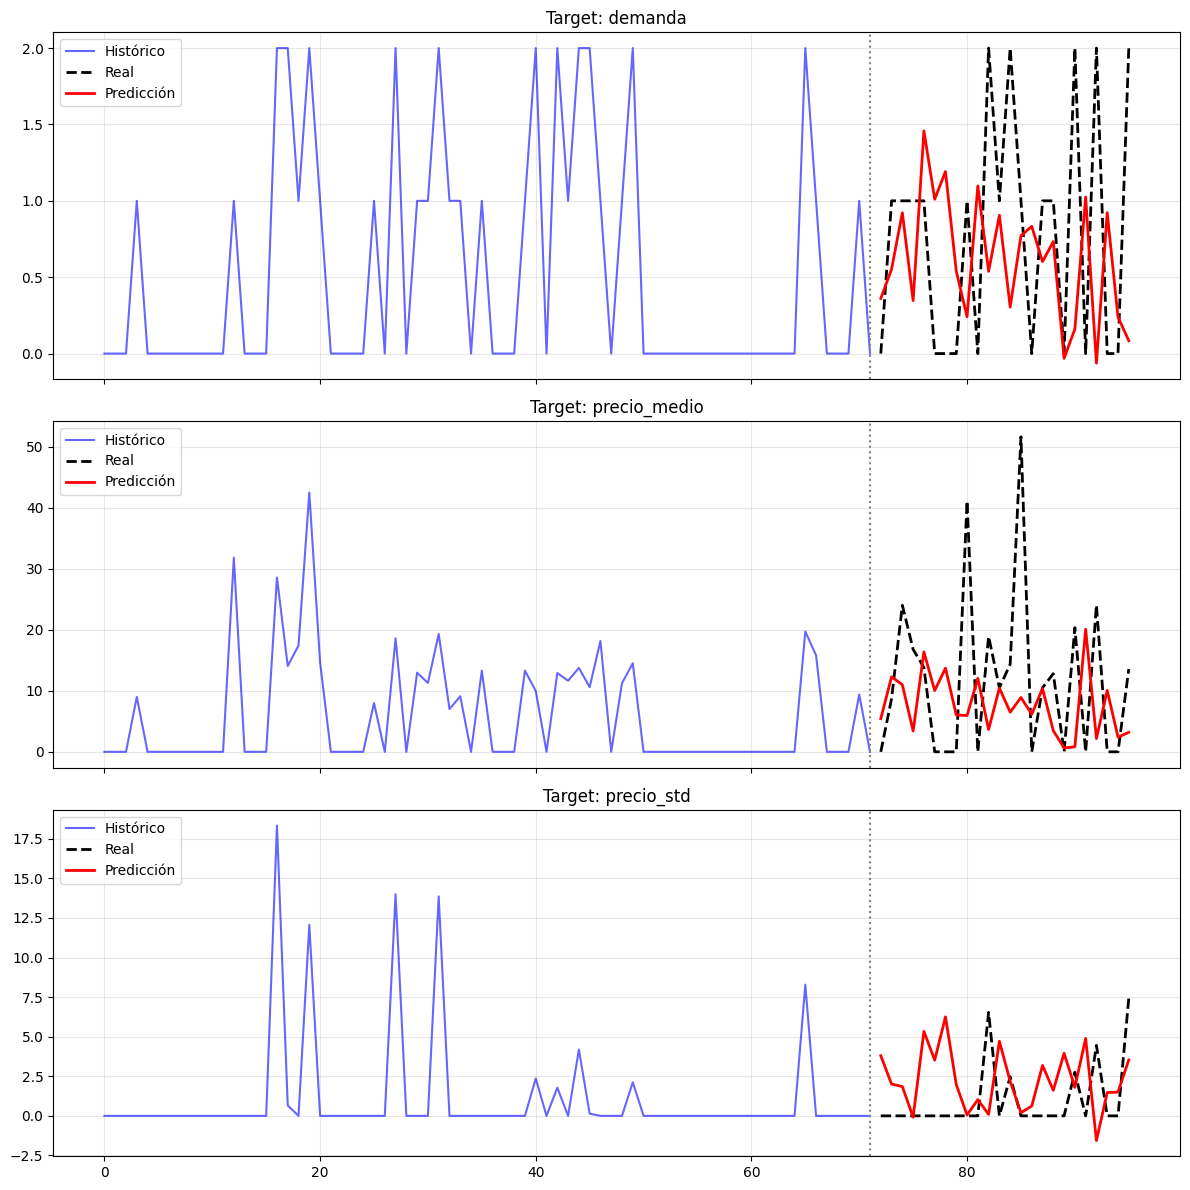

In [15]:
def plot_full_prediction(preds_output, training_dataset, vendor_id, location_id):
    predictions = preds_output[0]
    x_metadata = preds_output[1]

    group_ids = training_dataset.x_to_index(x_metadata)
    target_idx = group_ids[
        (group_ids["VendorID"] == vendor_id)
        & (group_ids["PULocationID"] == location_id)
    ].index

    if len(target_idx) == 0:
        print(f"Sin datos para Vendor {vendor_id}, Location {location_id}")
        return

    idx = target_idx[0]
    targets = ["demanda", "precio_medio", "precio_std"]
    fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

    for i, target in enumerate(targets):
        # CORRECCIÓN AQUÍ: Manejamos si es lista (multitarget) o tensor único
        if isinstance(x_metadata["encoder_target"], list):
            past_real = x_metadata["encoder_target"][i][idx].cpu()
            future_real = x_metadata["decoder_target"][i][idx].cpu()
            # Las predicciones también pueden venir como lista en multitarget
            future_pred = (
                predictions[i][idx].cpu()
                if isinstance(predictions, list)
                else predictions[idx, :, i].cpu()
            )
        else:
            past_real = x_metadata["encoder_target"][idx, :, i].cpu()
            future_real = x_metadata["decoder_target"][idx, :, i].cpu()
            future_pred = predictions[idx, :, i].cpu()

        x_past = np.arange(0, len(past_real))
        x_future = np.arange(len(past_real), len(past_real) + len(future_real))

        axes[i].plot(x_past, past_real, label="Histórico", color="blue", alpha=0.6)
        axes[i].plot(
            x_future, future_real, label="Real", color="black", lw=2, linestyle="--"
        )
        axes[i].plot(x_future, future_pred, label="Predicción", color="red", lw=2)

        axes[i].axvline(x=len(past_real) - 1, color="gray", linestyle=":")
        axes[i].set_title(f"Target: {target}")
        axes[i].legend(loc="upper left")
        axes[i].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


model.eval()

# Generamos las predicciones
# return_x=True es VITAL para que la función de dibujo tenga el pasado (histórico)
preds = model.predict(
    val_dataloader,
    mode="prediction",
    return_x=True,
    trainer_kwargs={"accelerator": "gpu"},  # Para que use tu 5070
)
plot_full_prediction(preds, training, vendor_id="0", location_id="7")

Como vemos este modelo no se ajuta a las condiciones de nuestro problema.

##### Webgrafía:

https://medium.com/@nasdag/tide-revolutionizing-long-term-time-series-forecasting-with-simple-mlp-architectures-21259cbe575b

https://towardsdatascience.com/tide-the-embarrassingly-simple-mlp-that-beats-transformers-7db77d588079/

https://pytorch-forecasting.readthedocs.io/en/v1.4.0/api/pytorch_forecasting.models.tide._tide.TiDEModel.html

https://pytorch-forecasting.readthedocs.io/en/v1.4.0/api/pytorch_forecasting.data.timeseries._timeseries.TimeSeriesDataSet.html

https://nixtlaverse.nixtla.io/neuralforecast/models.tide.html